# Numerik 2: Uebung 02
Bearbeitet von: Andres Jaramillo

In [1]:
import math
import itertools
import mpmath as mp
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def calcmaxiter(tol, K, d1):
    """ Gegeben eine Toleranz und eine Kontaktionskonstante fuer eine Iterfunk., 
        berechnet die anzahl an Iterationen um die Fehletoleranz zu erreichen
    
        Args:
            tol (float): Fehlertoleranz
            K   (float): Kontraktionskonstante
            d1  (float): || x(1) - x(0) ||
            
        Returns:
            int: Anzahl an Iterationen
    """

    # tol = (K^i)/(1-K) * d1 -> log_k(tol * (1-K)/d1) = i
    return int(mp.log(tol * (1-K)/d1, K)) + 1
    

In [16]:
def fixpunktiteration(f, x_0, tol, stoppkriterium, K):
    """ Führt das Fixpunkt-Verfahren aus
    
        Args:
            f   (float -> float): Die Funktion, auf die das Verfahren anzuwenden ist
            x_0 (float): Startwert
            tol  (float): Fehlertoleranz
            stoppkriterium (str): 'apriori' oder 'aposteriori'
            K (float): Kontraktionskonstante
    
        Returns:
            (float, int): Der Fixpunkt, die Anzahl an Iterationen
    """

    x_i = f(x_0)
    n = 1
    err = mp.inf
    n_max = None
    stop = lambda err, n: n >= n_max if n_max != None else err <= tol
    
    if stoppkriterium == 'apriori':
        n_max = calcmaxiter(tol, K, abs(x_0 - x_i))
    
    while not stop(err, n):
        x_ip1 = f(x_i)
        
        err = K/(1-K) * abs(x_i - x_ip1)
        x_i = x_ip1 
        n += 1
        
    return [x_i, n]

In [13]:
phi_3 = lambda x: 1 + x - (x**2) / 5
phi_4 = lambda x: 1/2  * (x + 5/x)

K_3 = 1/5
K_4 = 1/4

xpos_3_list = []
xpos_4_list = []

xpri_3_list = []
xpri_4_list = []
x_0 = 2.1

tol_list = np.logspace(-1,-15,50)
for tol in tol_list:
    xpos_3 = fixpunktiteration(phi_3, x_0, tol, 'aposteriori', K_3)
    xpos_4 = fixpunktiteration(phi_4, x_0, tol, 'aposteriori', K_4)
    
    xpri_3 = fixpunktiteration(phi_3, x_0, tol, 'apriori', K_3)
    xpri_4 = fixpunktiteration(phi_4, x_0, tol, 'apriori', K_4)

    xpos_3_list.append(xpos_3)
    xpos_4_list.append(xpos_4)
    xpri_3_list.append(xpri_3)
    xpri_4_list.append(xpri_4)


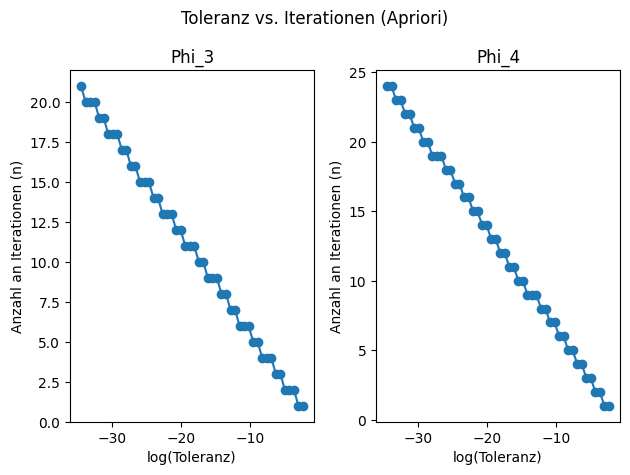

In [14]:

# Erstellen Sie damit jeweils eine Grafik f¨ur die a-posteriori und a-priori Fehlersch¨atzung,
# die die Anzahl der verwendete Iterationen (Y-Achse) und die gegebene Toleranz (X-Achse,
# logarithmisch)

# apriori
phi_3_y_vals = [n for (xs, n) in xpri_3_list]
phi_4_y_vals = [n for (xs, n) in xpri_4_list]

x_vals = [mp.log(tol) for tol in tol_list]
fig, (ax_3, ax_4) = plt.subplots(1, 2)
fig.suptitle("Toleranz vs. Iterationen (Apriori)")
ax_3.plot(x_vals, phi_3_y_vals, marker='o')
ax_3.set_title(f"Phi_3")
ax_3.set_ylabel("Anzahl an Iterationen (n)")
ax_3.set_xlabel(f"log(Toleranz)")

ax_4.plot(x_vals, phi_4_y_vals, marker='o')
ax_4.set_title(f"Phi_4")
ax_4.set_ylabel("Anzahl an Iterationen (n)")
ax_4.set_xlabel(f"log(Toleranz)")


plt.tight_layout()
plt.show()

100 100


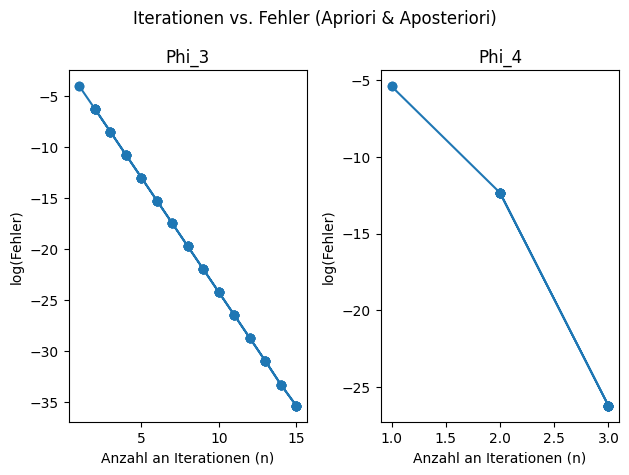

In [15]:
phi_3_x_vals = [n for (xs, n) in xpri_3_list] + [n for (xs, n) in xpos_3_list]
phi_4_x_vals = [n for (xs, n) in xpri_4_list] + [n for (xs, n) in xpos_4_list]


phi_3_y_vals = [mp.log(abs(xs - mp.sqrt(5))) for (xs, n) in xpri_3_list] + [mp.log(abs(xs - mp.sqrt(5))) for (xs, n) in xpos_3_list]
phi_4_y_vals = [mp.log(abs(xs - mp.sqrt(5))) for (xs, n) in xpri_4_list] + [mp.log(abs(xs - mp.sqrt(5))) for (xs, n) in xpos_4_list]

print(len(phi_4_x_vals), len(phi_4_y_vals))

fig, (ax_3, ax_4) = plt.subplots(1, 2)
fig.suptitle("Iterationen vs. Fehler (Apriori & Aposteriori)")
ax_3.plot(phi_3_x_vals, phi_3_y_vals, marker='o')
ax_3.set_title(f"Phi_3")
ax_3.set_xlabel("Anzahl an Iterationen (n)")
ax_3.set_ylabel(f"log(Fehler)")

ax_4.plot(phi_4_x_vals, phi_4_y_vals, marker='o')
ax_4.set_title(f"Phi_4")
ax_4.set_xlabel("Anzahl an Iterationen (n)")
ax_4.set_ylabel(f"log(Fehler)")


plt.tight_layout()
plt.show()

# Kommentar
Die Korvergenz von phi_3 ist, wie gedacht, linear. Die Konvergenz von Phi_4 zeigt eine Kruemmung, die ich glaube der quadratischen Konvergenz der Funktion zuzuschreiben ist, sieht aber bei diesen Daten nicht ganz glatt aus, aber ist jedenfalls nicht linear.

Interessanterweise ist die das Verhaeltnis zwischen Toleranz und Anzahl an Iterationen, verfahrensunabhaengig, linear.